In [1]:
from pathlib import Path
from collections.abc import Hashable
from typing import Generator
from anndata import AnnData
from itertools import product

import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from anndata import AnnData
from numpy.typing import NDArray
from pandas import DataFrame
from scipy.stats import spearmanr, pearsonr

from utils import (
    group_by_common_obs, 
    mean_randomized_cross_feature_prediction
)
from nmf_utils import nmf_predictor
from tangram_utils import tangram_predictor

In [2]:
def _adata_sp() -> AnnData:
    adata_sp: AnnData = sc.read(
        Path.cwd() / "data" / "inputQuery" / "gene_by_cell.csv",
    ).transpose()
    obs: DataFrame = sc.read_h5ad(Path.cwd() / "data" / "nico_out" / "nico_celltype_annotation.h5ad").obs
    adata_sp.obs = obs
    adata_sp.obs["celltype"] = adata_sp.obs["nico_ct"]
    #adata_sp = adata_sp[adata_sp.obs["celltype"] == celltype].copy()
    return adata_sp



def _adata_sc() -> AnnData:
    adata_sc: AnnData = sc.read_h5ad(Path.cwd() / "data" / "inputRef" / "input_ref.h5ad")
    adata_sc.obs["celltype"] = adata_sc.obs["cluster"]
    #adata_sc = adata_sc[adata_sc.obs["celltype"] == celltype].copy()
    adata_sc.X = adata_sc.X.toarray()
    return adata_sc

adata_sp: AnnData = _adata_sp()
adata_sc: AnnData = _adata_sc()

assert isinstance(adata_sp.X, np.ndarray)
assert isinstance(adata_sc.X, np.ndarray)

sc.pp.filter_genes(adata_sp, min_counts=1)
sc.pp.filter_genes(adata_sc, min_counts=1)

shared_genes = np.intersect1d(adata_sp.var_names, adata_sc.var_names)

print(f"{adata_sp=}\n{adata_sc=}")
print(f"{len(shared_genes)=}")

adata_sp=AnnData object with n_obs × n_vars = 7416 × 241
    obs: 'umi_sct', 'log_umi_sct', 'gene_sct', 'log_gene_sct', 'umi_per_gene_sct', 'log_umi_per_gene_sct', 'leiden0.4', 'leiden0.5', 'nico_ct', 'celltype'
    var: 'n_counts'
adata_sc=AnnData object with n_obs × n_vars = 2239 × 21197
    obs: 'cluster', 'celltype'
    var: 'n_counts'
len(shared_genes)=203


In [12]:
celltypes = list(adata_sp.obs["celltype"].unique())

In [14]:
celltype_counts = adata_sc.obs["celltype"].value_counts()
list(celltype_counts[celltype_counts >= 50].index)

['Stem/TA',
 'BZE',
 'Lymphatic',
 'Rest B',
 'Goblet',
 'Paneth',
 'Tuft',
 'Macrophage',
 'Plasma',
 'Stroma',
 'MZE',
 'T cell']

In [16]:
def filter_celltypes_by_size(
    adata: AnnData,
    obs_column: str,
    min_cell_count: int,
) -> AnnData:
    celltype_counts = adata.obs[obs_column].value_counts()
    valid_celltypes = list(celltype_counts[celltype_counts >= min_cell_count].index)
    return adata[adata.obs[obs_column].isin(valid_celltypes)].copy()

In [18]:
from functools import partial


adata_sp, adata_sc = map(
    partial(filter_celltypes_by_size, obs_column="celltype", min_cell_count=20),
    [adata_sp, adata_sc]
)

In [19]:
methods = {
    "nmf": nmf_predictor,
    "tangram": tangram_predictor
}

In [20]:
results = []

for (method_name, method), (celltype, query, reference) in product(methods.items(), group_by_common_obs(adata_sp, adata_sc, "celltype")):
    print(celltype)
    query_matrix = query[:, shared_genes].X
    reference_matrix = reference[:, shared_genes].X
    assert all(isinstance(m, np.ndarray) for m in (query_matrix, reference_matrix))
    
    reconstructed_counts = mean_randomized_cross_feature_prediction(
        query_matrix,
        reference_matrix,
        method,
        2,
        seed=5
    )
    
    score = float(spearmanr(query_matrix.mean(axis=0), reconstructed_counts.mean(axis=0))[0])
    results.append(((method_name, celltype), (query_matrix, reconstructed_counts)))

df = pd.DataFrame(results, columns=["index", "score"])
df.set_index("index", inplace=True)
df.index = pd.MultiIndex.from_tuples(df.index, names=["method", "celltype"])

BZE
Blood vasc.
max_iter exceeded, closest value found: 6
max_iter exceeded, closest value found: 4
max_iter exceeded, closest value found: 4
max_iter exceeded, closest value found: 6
max_iter exceeded, closest value found: 4
max_iter exceeded, closest value found: 6
Goblet
Lymphatic
MZE
Macrophage
max_iter exceeded, closest value found: 6
max_iter exceeded, closest value found: 4
max_iter exceeded, closest value found: 4
max_iter exceeded, closest value found: 6
Paneth
Plasma
Rest B
Stem/TA
Stroma
T cell
TZE
Tuft
cDC/monocyte
neurons/enteroendocrine


INFO:root:135 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:135 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.
INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 135 genes and rna_count_based density_prior in cells mode...


BZE


INFO:root:Printing scores every 100 epochs.


Score: 0.147, KL reg: 0.355
Score: 0.581, KL reg: 0.004
Score: 0.585, KL reg: 0.004
Score: 0.586, KL reg: 0.004
Score: 0.587, KL reg: 0.004
Score: 0.587, KL reg: 0.004
Score: 0.587, KL reg: 0.004
Score: 0.587, KL reg: 0.004
Score: 0.587, KL reg: 0.004
Score: 0.587, KL reg: 0.004


...

Score: 0.297, KL reg: 0.001
Score: 0.297, KL reg: 0.001
Score: 0.297, KL reg: 0.001
Score: 0.297, KL reg: 0.001
Score: 0.171, KL reg: 0.268
Score: 0.331, KL reg: 0.001
Score: 0.334, KL reg: 0.001
Score: 0.334, KL reg: 0.001
Score: 0.334, KL reg: 0.001
Score: 0.335, KL reg: 0.001


INFO:root:Saving results..
INFO:root:136 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:136 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.
INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 136 genes and rna_count_based density_prior in cells mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.335, KL reg: 0.001
Score: 0.335, KL reg: 0.001
Score: 0.335, KL reg: 0.001
Score: 0.335, KL reg: 0.001
Score: 0.164, KL reg: 0.261
Score: 0.328, KL reg: 0.001
Score: 0.331, KL reg: 0.001
Score: 0.331, KL reg: 0.001
Score: 0.332, KL reg: 0.001
Score: 0.332, KL reg: 0.001


INFO:root:Saving results..


Score: 0.332, KL reg: 0.001
Score: 0.332, KL reg: 0.001
Score: 0.332, KL reg: 0.001
Score: 0.332, KL reg: 0.001


In [21]:
df_spearman = pd.DataFrame(df["score"].map(lambda t: float(spearmanr(t[0].mean(axis=0), t[1].mean(axis=0))[0])))

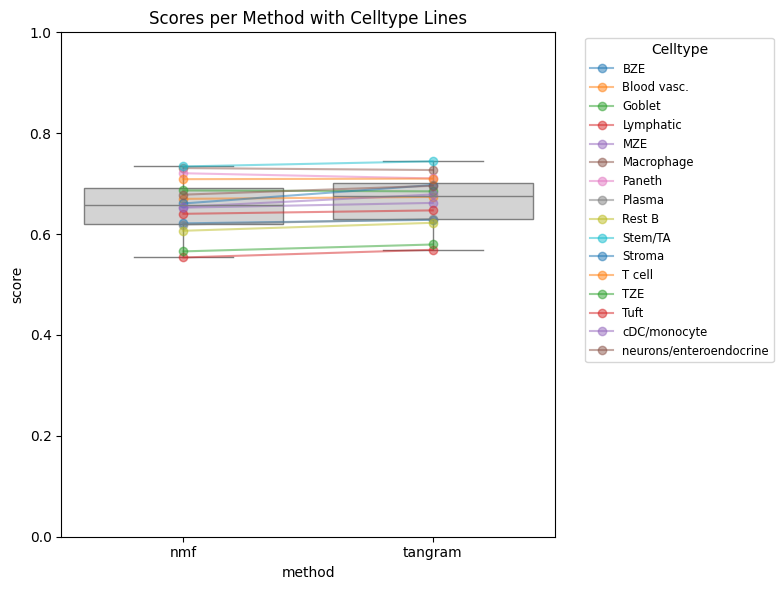

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_reset = df_spearman.reset_index()

plt.figure(figsize=(8, 6))

sns.boxplot(data=df_reset, x="method", y="score", color="lightgray")

for celltype, group in df_reset.groupby("celltype"):
    plt.plot(group["method"], group["score"], marker="o", label=celltype, alpha=0.5)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small", title="Celltype")
plt.title("Scores per Method with Celltype Lines")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [23]:
df_pearson = pd.DataFrame(df["score"].map(lambda t: float(pearsonr(t[0].mean(axis=0), t[1].mean(axis=0))[0])))

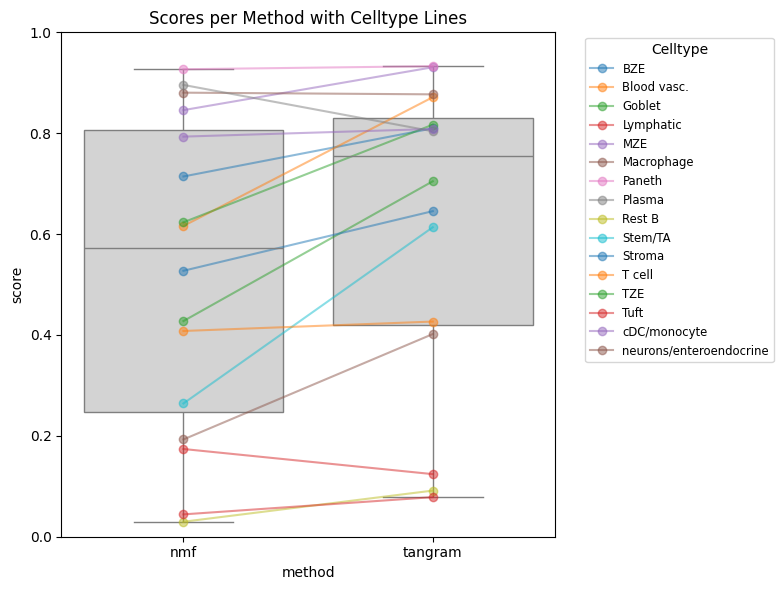

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_reset = df_pearson.reset_index()

plt.figure(figsize=(8, 6))

sns.boxplot(data=df_reset, x="method", y="score", color="lightgray")

for celltype, group in df_reset.groupby("celltype"):
    plt.plot(group["method"], group["score"], marker="o", label=celltype, alpha=0.5)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small", title="Celltype")
plt.title("Scores per Method with Celltype Lines")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()